

# Project: Investigate a Dataset - [TMDB Movies Analysis]

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction
 
In this project, I will analyze the TMDB Movies dataset using multiple criteria, including genres, release year, vote average, and other relevant features. The goal is to explore the dataset and answer several questions related to movie trends, popularity, and other aspects of the film industry.

The analysis will involve cleaning the data, handling missing or duplicate values, and performing exploratory data analysis (EDA) to gain insights into patterns and relationships within the dataset.



### **Questions for Analysis**
1. Which genre appears most frequently in the dataset?
2. Which movie has the highest revenue?
3. Which movie has the lowest revenue?
4. Which movie is the most popular?
5. Do movies with higher budgets generate higher revenue?
6. Do movies with higher average ratings generate more revenue?
7. Does movie runtime affect movie revenue?
8. Does the number of votes a movie receives influence its revenue?
9. Has movie popularity increased over the years?




In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

<a id='wrangling'></a>
## Data Wrangling




### **General Properties**
> 

**Loading the dataset to get an overview by displaying a sample of it.** 

In [ ]:
# Load the TMDB movies dataset from CSV and display the first few rows

df = pd.read_csv('tmdb-movies.csv')

df.head()


,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


**To know the size of the Data Frame, I use the shape method with return (number of rows, number of columns).**

In [ ]:
# Check the number of rows and columns in the dataset

df.shape

(10866, 21)

**To obtain the dataset's summary statistics.**

In [ ]:
# Generate summary statistics (count, mean, std, min, max, quartiles) for numeric columns

df.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10866.000000,10866.000000,1.086600e+04,1.086600e+04,10866.000000,10866.000000,10866.000000,10866.000000,1.086600e+04,1.086600e+04
mean,66064.177434,0.646441,1.462570e+07,3.982332e+07,102.070863,217.389748,5.974922,2001.322658,1.755104e+07,5.136436e+07
std,92130.136561,1.000185,3.091321e+07,1.170035e+08,31.381405,575.619058,0.935142,12.812941,3.430616e+07,1.446325e+08
min,5.000000,0.000065,0.000000e+00,0.000000e+00,0.000000,10.000000,1.500000,1960.000000,0.000000e+00,0.000000e+00
25%,10596.250000,0.207583,0.000000e+00,0.000000e+00,90.000000,17.000000,5.400000,1995.000000,0.000000e+00,0.000000e+00
50%,20669.000000,0.383856,0.000000e+00,0.000000e+00,99.000000,38.000000,6.000000,2006.000000,0.000000e+00,0.000000e+00
75%,75610.000000,0.713817,1.500000e+07,2.400000e+07,111.000000,145.750000,6.600000,2011.000000,2.085325e+07,3.369710e+07
max,417859.000000,32.985763,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09


**To know the number of non null values in each column and the datatype of each one, I use info() method.**

In [ ]:
# Display concise summary of the dataset, including column names, data types, and non-null counts

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  str    
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  str    
 6   cast                  10790 non-null  str    
 7   homepage              2936 non-null   str    
 8   director              10822 non-null  str    
 9   tagline               8042 non-null   str    
 10  keywords              9373 non-null   str    
 11  overview              10862 non-null  str    
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  str    
 14  production_companies  9836 non-null   str    
 15  release_date          10866 no

**I dropped the columns that are not needed for my analysis (since they are not used in the questions above) using the drop() method. Then, I displayed a sample of the dataset to confirm that the columns were successfully removed.**

In [ ]:
df.drop(['id', 'imdb_id','cast', 'homepage', 'director', 'tagline', 'keywords', 'overview','production_companies', 'release_date','budget', 'revenue'],axis=1, inplace = True)

In [16]:
df.head()

,popularity,original_title,runtime,genres,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,32.985763,Jurassic World,124,Action|Adventure|Science Fiction|Thriller,5562,6.5,2015,1.379999e+08,1.392446e+09
1,28.419936,Mad Max: Fury Road,120,Action|Adventure|Science Fiction|Thriller,6185,7.1,2015,1.379999e+08,3.481613e+08
2,13.112507,Insurgent,119,Adventure|Science Fiction|Thriller,2480,6.3,2015,1.012000e+08,2.716190e+08
3,11.173104,Star Wars: The Force Awakens,136,Action|Adventure|Science Fiction|Fantasy,5292,7.5,2015,1.839999e+08,1.902723e+09
4,9.335014,Furious 7,137,Action|Crime|Thriller,2947,7.3,2015,1.747999e+08,1.385749e+09


**Now, I want check again the number of non null values in each column after dropping operation, using info() method.**

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   popularity      10866 non-null  float64
 1   original_title  10866 non-null  str    
 2   runtime         10866 non-null  int64  
 3   genres          10843 non-null  str    
 4   vote_count      10866 non-null  int64  
 5   vote_average    10866 non-null  float64
 6   release_year    10866 non-null  int64  
 7   budget_adj      10866 non-null  float64
 8   revenue_adj     10866 non-null  float64
dtypes: float64(4), int64(3), str(2)
memory usage: 764.1 KB


**I found that 'genres' column have 23 null values, and to handle it I will delete the null rows.**

In [ ]:
# Remove rows where the 'genres' column is null

df = df[df['genres'].notnull()]

**Now, I want to check the size of the dataset after dropping the rows with null values and removing the unneeded columns.**

In [ ]:
# Check the number of rows and columns in the dataset

df.shape

(10843, 9)

**Now, I checked the dataset to see if there are any null values.**

In [ ]:
# Check for missing values in each column of the dataset

df.isnull().sum()

popularity        0
original_title    0
runtime           0
genres            0
vote_count        0
vote_average      0
release_year      0
budget_adj        0
revenue_adj       0
dtype: int64

**Now, I will examine the data type of each column to ensure it is suitable for the intended analysis.**

In [ ]:
# Check the data types of each column in the dataset

df.dtypes

popularity        float64
original_title        str
runtime             int64
genres                str
vote_count          int64
vote_average      float64
release_year        int64
budget_adj        float64
revenue_adj       float64
dtype: object

**After examining the dataset, I found that the data type of each column is appropriate, so no modifications are needed.**

**I will now check for duplicates in the dataset.**

In [ ]:
# Count the number of duplicate rows in the dataset

sum(df.duplicated())

1

**I found one duplicated row in the dataset and dropped it.**

In [ ]:
# Remove duplicate rows from the dataset

df.drop_duplicates(inplace = True)

**I checked again to ensure that the duplicate row has been successfully deleted.**

In [27]:
sum(df.duplicated())

0

**While obtaining the dataset's summary statistics, I noticed that the budget_adj, revenue_adj, and runtime columns contained zero values, which are not logical. Therefore, I calculated the median for the runtime and the mean for the budget_adj, revenue_adj columns and replaced the zero values with the median, mean to ensure a more accurate analysis.**

In [ ]:
# Compute mean revenue, mean budget, and median runtime
mean_revenue = df['revenue_adj'].mean()
mean_budget = df['budget_adj'].mean()
median_runtime = df['runtime'].median()

In [ ]:
# Print the calculated mean revenue, mean budget, and median runtime

print(f"Mean Revenue: {mean_revenue}")
print(f"Mean Budget: {mean_budget}")
print(f"Median Runtime: {median_runtime}")

Mean Revenue: 51477974.9225074
Mean Budget: 17587121.43826287
Median Runtime: 99.0


In [ ]:
# Replace zero values in revenue, budget, and runtime with their respective mean or median

df['revenue_adj'] = np.where(df['revenue_adj'] == 0, mean_revenue, df['revenue_adj'])
df['budget_adj'] = np.where(df['budget_adj'] == 0, mean_budget, df['budget_adj'])
df['runtime'] = np.where(df['runtime'] == 0, median_runtime, df['runtime'])

In [63]:
df.describe()

,popularity,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10842.000000,10842.000000,10842.000000,10842.000000,10842.000000,1.084200e+04,1.084200e+04
mean,0.647461,102.412378,217.823649,5.974064,2001.314794,2.679108e+07,7.993283e+07
std,1.001032,30.829143,576.180993,0.934257,12.813617,3.053264e+07,1.366907e+08
min,0.000065,2.000000,10.000000,1.500000,1960.000000,9.210911e-01,2.370705e+00
25%,0.208210,90.000000,17.000000,5.400000,1995.000000,1.758712e+07,5.147797e+07
50%,0.384532,99.000000,38.000000,6.000000,2006.000000,1.758712e+07,5.147797e+07
75%,0.715393,111.000000,146.000000,6.600000,2011.000000,2.092507e+07,5.147797e+07
max,32.985763,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09



**I noticed that the genres column contains multiple movie types in the same cell, such as "Action|Adventure|Fantasy". Therefore, I created a copy of the dataset to process the genres column safely without modifying the original dataset. The column was then split using the "|" separator and expanded so that each genre appears in a separate row, allowing for accurate counting of each genre.**


In [41]:
# Create a copy of the dataset to avoid modifying the original DataFrame
# Split the 'genres' column on "|" to separate multiple genres
# Expand the list of genres so that each genre appears in its own row
df_genres = df.copy()
df_genres['genres'] = df_genres['genres'].str.split('|')
df_genres = df_genres.explode('genres')

<a id='eda'></a>
## Exploratory Data Analysis


### Research Question 1 (Which genre appears most frequently in the dataset?)

**To understand which genres appear most frequently in the dataset, I first calculated the number of movies for each genre using the value_counts() function. This produces a frequency distribution of genres, allowing us to identify the top 10 most common genres in the dataset.**

In [ ]:
# Count the number of movies in each genre and display the top 10 most frequent genres

genre_counts = df_genres['genres'].value_counts()
print("Top 10 Most Frequent Genres:\n", genre_counts.head(10))

Top 10 Most Frequent Genres:
 genres
Drama              4760
Comedy             3793
Thriller           2907
Action             2384
Romance            1712
Horror             1637
Adventure          1471
Crime              1354
Family             1231
Science Fiction    1229
Name: count, dtype: int64


**To visualize the distribution of movie genres, a bar plot was created. This plot shows the number of movies for the top 10 genres, making it easy to compare which genres are most common.**

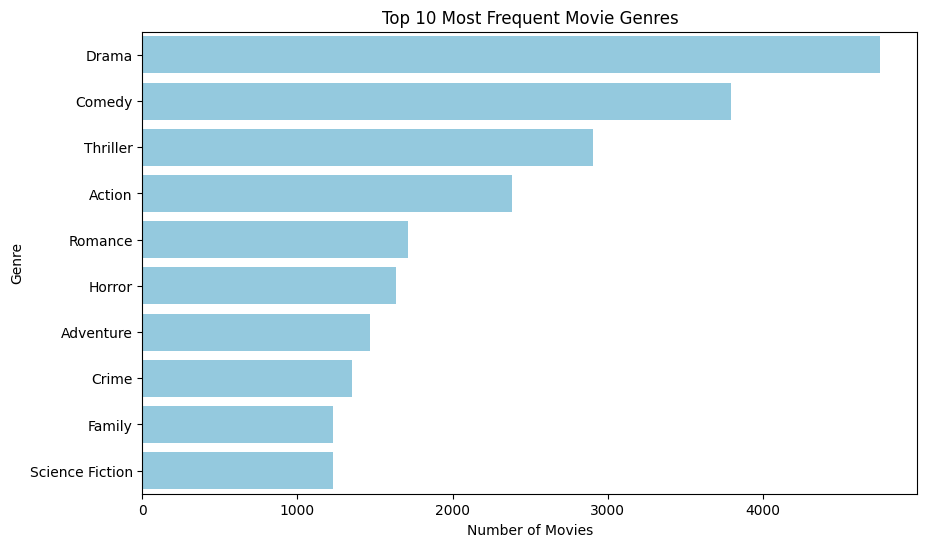

In [ ]:
# Plot a horizontal bar chart of the top 10 most frequent movie genres

top10_genres = genre_counts.head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top10_genres.values, y=top10_genres.index, color='skyblue')  # استخدم color بدل palette
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.title("Top 10 Most Frequent Movie Genres")
plt.show()

**The bar chart shows the Top 10 most frequent movie genres in the dataset. From the chart, we can see that [Drama] appears the most, followed by [Comedy], [Thriller], etc. This indicates that these genres are the most commonly produced movies in the dataset.**

### Research Question 2  (Which movie has the highest revenue?)

**Find the Movie with Highest Revenue**

In [ ]:
# Find the movie(s) with the highest revenue and display the revenue amount

max_revenue = df['revenue_adj'].max()

top_movie = df[df['revenue_adj'] == max_revenue]['original_title'].tolist()
print("Movie(s) with the Highest Revenue:", top_movie[0])
print("Highest Revenue: ${:,.2f}".format(max_revenue))

Movie(s) with the Highest Revenue: Avatar
Highest Revenue: $2,827,123,750.41


**Distribution of Revenue**

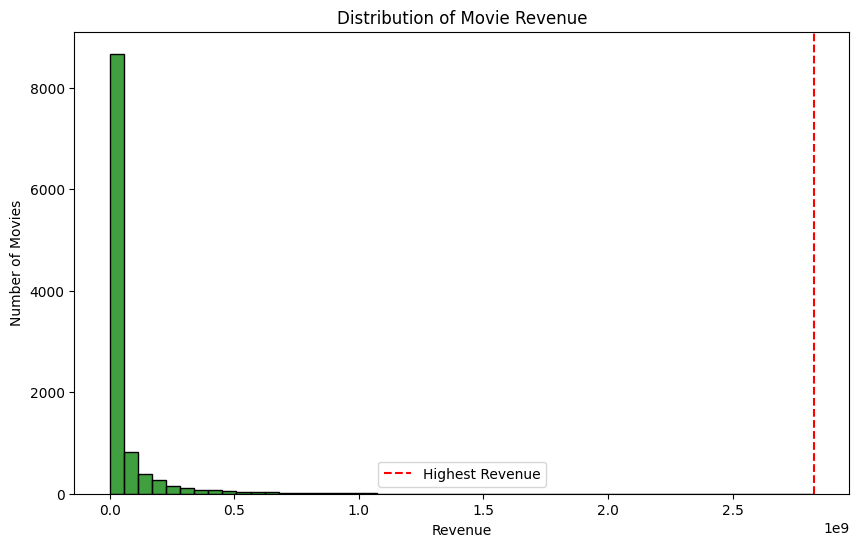

In [ ]:
# Plot the distribution of movie revenues using a histogram
# Highlight the highest revenue with a red dashed line

plt.figure(figsize=(10,6))
sns.histplot(df['revenue_adj'], bins=50, color='green')
plt.axvline(max_revenue, color='red', linestyle='--', label='Highest Revenue')
plt.xlabel("Revenue")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Revenue")
plt.legend()
plt.show()

**The movie with the highest revenue in the dataset is [Avatar], earning [$2,827,123,750.41].From the histogram, we can see that most movies earn significantly less, indicating that this movie is an outlier in revenue. This 1D analysis shows the scale difference between blockbuster movies and typical films.**


### Research Question 3  (Which movie has the lowest revenue?)

**Find the Movie with Lowest Revenue**

In [ ]:
# Find the movie(s) with the lowest revenue and display the revenue amount

min_revenue = df['revenue_adj'].min()

lowest_movie = df[df['revenue_adj'] == min_revenue]['original_title'].tolist()
print("Movie(s) with the Lowest Revenue:", lowest_movie[0])
print("Lowest Revenue: ${:,.2f}".format(min_revenue))

Movie(s) with the Lowest Revenue: Shattered Glass
Lowest Revenue: $2.37


**The movie with the lowest revenue in the dataset is [Shattered Glass], earning [$2.37].**


### Research Question 4  (Which movie is the most popular?)

**Find the Movie with Highest Popularit**

In [ ]:
# Find the maximum popularity score in the dataset
max_popularity = df['popularity'].max()

# Identify the movie(s) with the highest popularity
most_popular_movie = df[df['popularity'] == max_popularity]['original_title'].tolist()

# Print the most popular movie and its popularity score
print("Most Popular Movie:", most_popular_movie[0])
print("Popularity Score:", max_popularity)

Most Popular Movie: Jurassic World
Popularity Score: 32.985763


**The most popular movie in the dataset is [Jurassic World], with a popularity score of [32.985763].**

### Research Question 5  (Do movies with higher budgets generate higher revenue?)

**Check summary statistics for budget_adj and revenue_adj**

In [ ]:
# Display summary statistics for budget and revenue (adjusted)

print("Budget Summary:")
print(df['budget_adj'].describe())
print("\nRevenue Summary:")
print(df['revenue_adj'].describe())

Budget Summary:
count    1.084200e+04
mean     2.679108e+07
std      3.053264e+07
min      9.210911e-01
25%      1.758712e+07
50%      1.758712e+07
75%      2.092507e+07
max      4.250000e+08
Name: budget_adj, dtype: float64

Revenue Summary:
count    1.084200e+04
mean     7.993283e+07
std      1.366907e+08
min      2.370705e+00
25%      5.147797e+07
50%      5.147797e+07
75%      5.147797e+07
max      2.827124e+09
Name: revenue_adj, dtype: float64


**To avoid repeating the same plotting code, I created a reusable function called plot_scatter().**
**This function generates a scatter plot by taking the dataset, column names, labels, title, and color as inputs.**
**It helps simplify the code and ensures consistency across all visualizations.**

In [ ]:
# Reusable function to create scatter plots for analyzing relationships between variables

def plot_scatter(data, x_col, y_col, x_label, y_label, title, color):
    plt.figure(figsize=(10,6))
    sns.scatterplot(x=x_col, y=y_col, data=data, alpha=0.6, color=color)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.show()

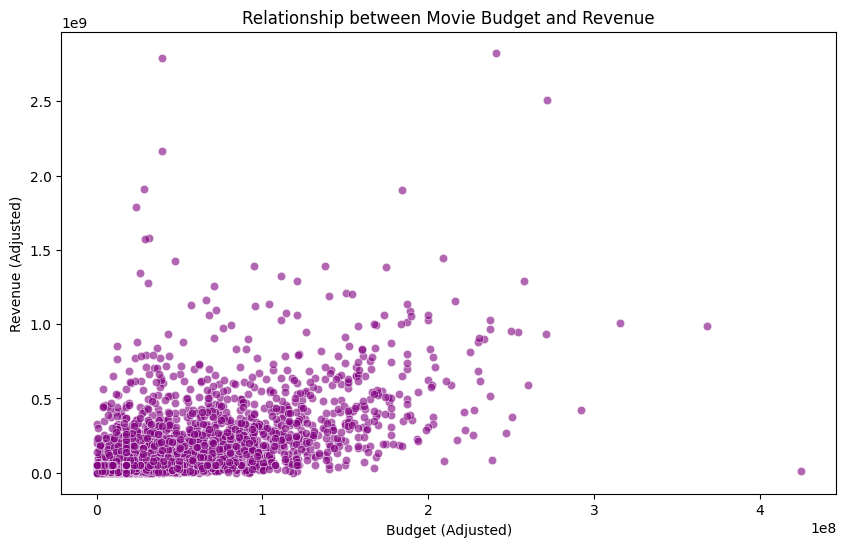

In [ ]:
# Plot the relationship between movie budget and revenue using the reusable scatter plot function

plot_scatter(
    df,
    'budget_adj',
    'revenue_adj',
    'Budget (Adjusted)',
    'Revenue (Adjusted)',
    'Relationship between Movie Budget and Revenue',
    'purple'
)

**Calculate correlation**

In [ ]:
# Calculate correlation between budget_adj and revenue_adj
correlation = df['budget_adj'].corr(df['revenue_adj'])
print("Correlation between Budget and Revenue:", round(correlation, 2))

Correlation between Budget and Revenue: 0.6


**The scatter plot shows a moderate positive correlation (0.6) between movie budget and revenue. While higher budgets generally correspond to higher revenues, the relationship is not perfect. Some low-budget films still achieve impressive revenues, and a few high-budget films underperform. Outliers represent exceptionally successful blockbusters, highlighting variability in movie performance.**

### Research Question 6  (Do movies with higher average ratings generate more revenue?)

**Check summary statistics for vote_average and revenue_adj**

In [ ]:
# Display summary statistics for vote_average and revenue (adjusted)

print("Vote Average Summary:")
print(df['vote_average'].describe())
print("\nRevenue Summary:")
print(df['revenue_adj'].describe())

Vote Average Summary:
count    10842.000000
mean         5.974064
std          0.934257
min          1.500000
25%          5.400000
50%          6.000000
75%          6.600000
max          9.200000
Name: vote_average, dtype: float64

Revenue Summary:
count    1.084200e+04
mean     7.993283e+07
std      1.366907e+08
min      2.370705e+00
25%      5.147797e+07
50%      5.147797e+07
75%      5.147797e+07
max      2.827124e+09
Name: revenue_adj, dtype: float64


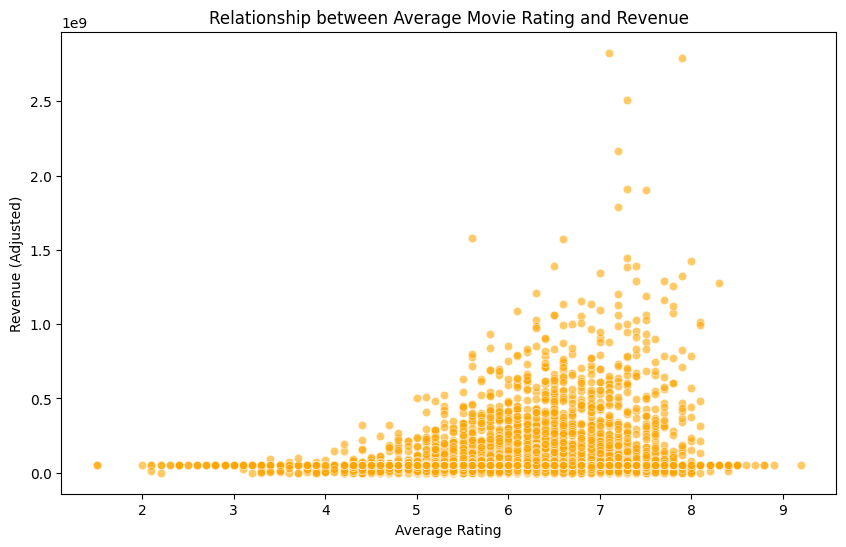

In [ ]:
# Plot the relationship between vote_average and revenue_adj using the reusable scatter plot function

plot_scatter(
    df,
    'vote_average',
    'revenue_adj',
    'Average Rating',
    'Revenue (Adjusted)',
    'Relationship between Average Movie Rating and Revenue',
    'orange'
)

In [ ]:
# Calculate correlation between vote_average and revenue_adj
correlation_rating = df['vote_average'].corr(df['revenue_adj'])
print("Correlation between Vote Average and Revenue:", round(correlation_rating, 2))

Correlation between Vote Average and Revenue: 0.17


**The scatter plot shows a weak positive relationship between average movie ratings and revenue (correlation = 0.17). While some higher-rated movies earn more revenue, the relationship is not strong. Many high-revenue movies have only moderate ratings, and some highly-rated films earn relatively low revenue. This indicates that higher ratings do not guarantee higher revenue**

### Research Question 7  (Does movie runtime affect movie revenue?)

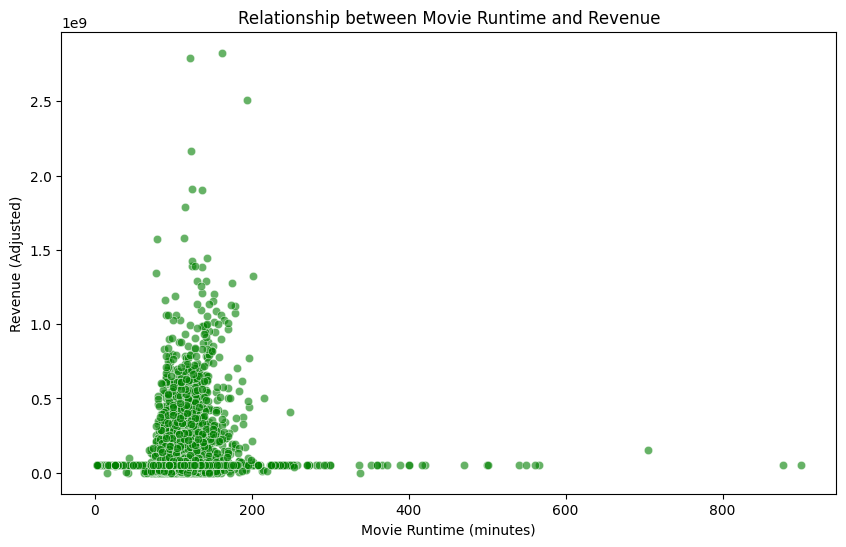

In [ ]:
# Plot the relationship between runtime and revenue_adj using the reusable scatter plot function

plot_scatter(
    df,
    'runtime',
    'revenue_adj',
    'Movie Runtime (minutes)',
    'Revenue (Adjusted)',
    'Relationship between Movie Runtime and Revenue',
    'green'
)

**Calculate Correlation**

In [ ]:
# Calculate correlation between runtime and revenue_adj
correlation_runtime = df['runtime'].corr(df['revenue_adj'])
print("Correlation between Runtime and Revenue:", round(correlation_runtime, 2))

Correlation between Runtime and Revenue: 0.16


**The scatter plot and correlation analysis show a very weak positive relationship between movie runtime and revenue (correlation = 0.16). This indicates that movie runtime does not significantly affect revenue. While some longer movies generate high revenues, many shorter films also perform well. Therefore, runtime alone is not a strong predictor of a movie’s financial success.**

### Research Question 8  (Does the number of votes a movie receives influence its revenue?)

**Scatter Plot**

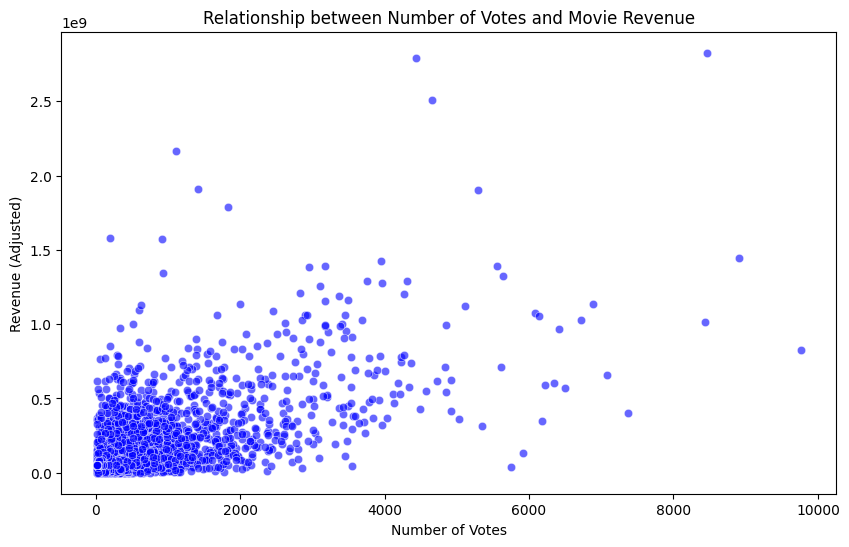

In [ ]:
# Plot the relationship between vote_count and revenue_adj using the reusable scatter plot function

plot_scatter(
    df,
    'vote_count',
    'revenue_adj',
    'Number of Votes',
    'Revenue (Adjusted)',
    'Relationship between Number of Votes and Movie Revenue',
    'blue'
)

**Calculate Correlation**

In [ ]:
# Calculate correlation between vote_count and revenue_adj
correlation_votes = df['vote_count'].corr(df['revenue_adj'])
print("Correlation between Vote Count and Revenue:", round(correlation_votes, 2))

Correlation between Vote Count and Revenue: 0.69


**Based on the scatter plot between the number of votes and movie revenue, as well as the correlation analysis, movies that receive a higher number of votes tend to generate higher revenue.**

### Research Question 9  (Has movie popularity increased over the years?)

**To analyze the trend of movie popularity over time, I calculated the average popularity for movies in each release year using the groupby() function.**

In [ ]:
# Calculate the average popularity of movies for each release year
popularity_by_year = df.groupby('release_year')['popularity'].mean()

# Display the first few years and their average popularity
print(popularity_by_year.head())

release_year
1960    0.458932
1961    0.422827
1962    0.454783
1963    0.502706
1964    0.412428
Name: popularity, dtype: float64


**Line Plot**

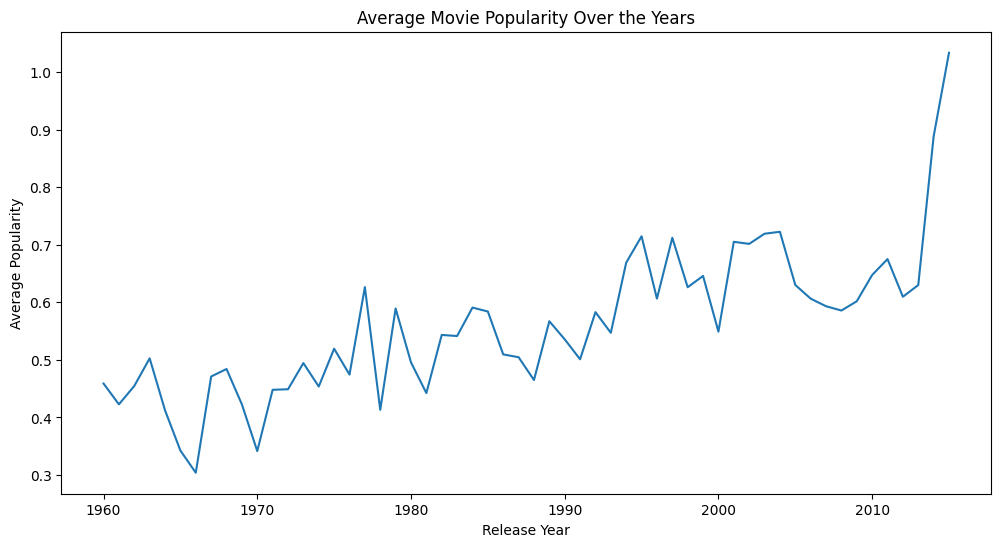

In [ ]:
# Plot the trend of average movie popularity over the years using a line plot

plt.figure(figsize=(12,6))
sns.lineplot(x=popularity_by_year.index, y=popularity_by_year.values)

plt.xlabel("Release Year")
plt.ylabel("Average Popularity")
plt.title("Average Movie Popularity Over the Years")

plt.show()

**The line plot indicates that movie popularity has generally increased over time, especially in recent years.**

<a id='conclusions'></a>
## Conclusions

**After analyzing the dataset, several insights emerged:**
1. Genre Analysis: Action, Drama, and Comedy are among the most frequent genres in the dataset.
2. Revenue Extremes: 'Avatar' has the highest revenue, while some low-budget films generated very low revenue.
3. Popularity: Movies released in recent years tend to have higher popularity scores, showing a general upward trend over time.
4. Budget vs Revenue: There is a moderate positive correlation (0.6) between budget and revenue, indicating that higher-budget films generally generate higher revenue, although exceptions exist.
5. Average Ratings vs Revenue: The correlation between vote average and revenue is very weak (0.17), suggesting that higher ratings alone do not guarantee higher earnings.
6. Runtime vs Revenue: The correlation between runtime and revenue is also very weak (0.16), showing that movie length has little impact on revenue.
7. Vote Count vs Revenue: A stronger correlation (0.69) exists between vote count and revenue, implying that more popular films with higher audience engagement tend to earn more.
8. Trends over Time: Movie popularity has generally increased over the years, reflecting the growing global audience and digital platforms.


Financial success of movies is influenced by multiple factors. Budget and audience engagement (vote count) show the strongest relationships with revenue, while runtime and average rating are less influential. Popularity tends to increase over time, highlighting trends in audience behavior and industry growth.

**Limitations:**

  1. Some movies belong to multiple genres, so the counts may include movies in more than one category.
  2. Missing or Zero Values: Some movies had missing or zero values for revenue and budget, which were replaced with mean values. This may affect the accuracy of correlation and trend analysis.
  3. External Factors: Revenue and popularity are influenced by marketing, distribution, seasonality, and social media, which are not captured in this dataset.